Running comparison...


Performance Comparison Table

   Array Size  Binary Comparisons  Binary Time(s)  Interpolation Comparisons  \
0        1000                   9        0.000006                          2   
1        5000                  12        0.000005                          2   
2       10000                  13        0.000004                          2   
3       50000                  15        0.000007                          2   
4      100000                  16        0.000007                          2   

   Interpolation Time(s)  
0               0.000004  
1               0.000002  
2               0.000002  
3               0.000002  
4               0.000004  

Complexity Analysis
----------------------------------------
Binary Search:
Time Complexity : O(log n)
Space Complexity: O(1)

Interpolation Search:
Best Case       : O(1)
Average Case    : O(log log n)
Worst Case      : O(n)
Space Complexity: O(1)


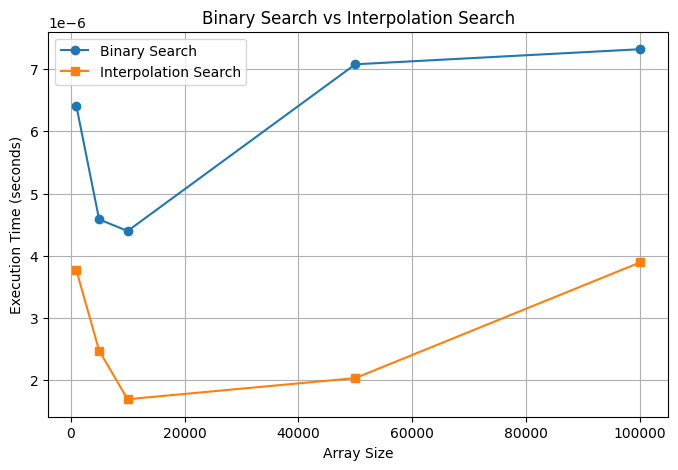

In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------
# Binary Search
# ----------------------------------
def binary_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    start = time.perf_counter()

    while low <= high:
        comparisons += 1

        mid = (low + high) // 2

        if arr[mid] == key:
            end = time.perf_counter()
            return comparisons, end - start

        elif arr[mid] < key:
            low = mid + 1

        else:
            high = mid - 1

    end = time.perf_counter()
    return comparisons, end - start


# ----------------------------------
# Interpolation Search
# ----------------------------------
def interpolation_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    start = time.perf_counter()

    while (low <= high and
           key >= arr[low] and
           key <= arr[high]):

        comparisons += 1

        if low == high:
            if arr[low] == key:
                end = time.perf_counter()
                return comparisons, end - start
            break

        pos = low + int(
            ((high - low) /
             (arr[high] - arr[low])) *
            (key - arr[low])
        )

        comparisons += 1

        if arr[pos] == key:
            end = time.perf_counter()
            return comparisons, end - start

        elif arr[pos] < key:
            low = pos + 1

        else:
            high = pos - 1

    end = time.perf_counter()
    return comparisons, end - start


# ----------------------------------
# Dataset Sizes
# ----------------------------------
sizes = [1000, 5000, 10000, 50000, 100000]

results = []

print("Running comparison...\n")

for n in sizes:

    # Uniformly distributed sorted dataset
    arr = list(range(1, n + 1))

    # Search key
    key = arr[n // 2]

    # Binary Search
    b_comp, b_time = binary_search(arr, key)

    # Interpolation Search
    i_comp, i_time = interpolation_search(arr, key)

    results.append([
        n,
        b_comp,
        b_time,
        i_comp,
        i_time
    ])

# ----------------------------------
# Results Table
# ----------------------------------
df = pd.DataFrame(results, columns=[
    "Array Size",
    "Binary Comparisons",
    "Binary Time(s)",
    "Interpolation Comparisons",
    "Interpolation Time(s)"
])

print("\nPerformance Comparison Table\n")
print(df)

# ----------------------------------
# Complexity Information
# ----------------------------------
print("\nComplexity Analysis")
print("-" * 40)
print("Binary Search:")
print("Time Complexity : O(log n)")
print("Space Complexity: O(1)")

print("\nInterpolation Search:")
print("Best Case       : O(1)")
print("Average Case    : O(log log n)")
print("Worst Case      : O(n)")
print("Space Complexity: O(1)")

# ----------------------------------
# Plot Graph
# ----------------------------------
plt.figure(figsize=(8,5))

plt.plot(
    df["Array Size"],
    df["Binary Time(s)"],
    marker='o',
    label="Binary Search"
)

plt.plot(
    df["Array Size"],
    df["Interpolation Time(s)"],
    marker='s',
    label="Interpolation Search"
)

plt.xlabel("Array Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Binary Search vs Interpolation Search")
plt.legend()
plt.grid(True)

plt.show()